In [ ]:
#!pip install pandas scikit-learn nltk matplotlib seaborn

Logistic Regression

Linear SVM

In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\owzya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
data = pd.read_csv(
    "data.csv",
    sep="\t"
)

data.head()

,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


In [3]:
print(data.shape)
print(data.columns)

(90000, 2)
Index(['review', 'sentiment'], dtype='object')


In [4]:
data["sentiment"] = data["sentiment"].replace({
    "neautral": "neutral"
})

In [5]:
data["sentiment"].value_counts()

sentiment
negative    30000
neutral     30000
positive    30000
Name: count, dtype: int64

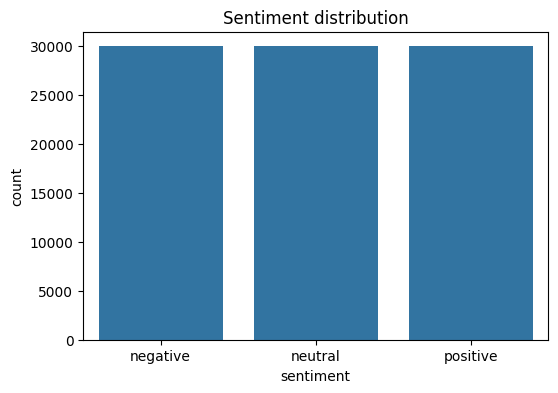

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x=data["sentiment"])
plt.title("Sentiment distribution")
plt.show()

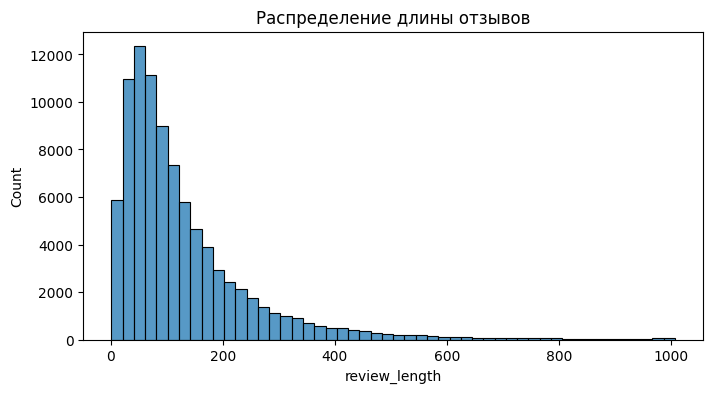

In [7]:
data["review_length"] = data["review"].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(data["review_length"], bins=50)
plt.title("Распределение длины отзывов")
plt.show()

In [8]:
russian_stopwords = set(stopwords.words("russian"))

In [9]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Zа-яё0-9\s]", " ", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in russian_stopwords]

    return " ".join(tokens)

In [10]:
data["clean_text"] = data["review"].apply(preprocess)

data.head()

,review,sentiment,review_length,clean_text
0,качество плохое пошив ужасный (горловина напер...,negative,172,качество плохое пошив ужасный горловина напере...
1,"Товар отдали другому человеку, я не получила п...",negative,80,товар отдали другому человеку получила посылку...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,204,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,86,товар пришел продавец продлил защиту моего сог...
4,"Кофточка голая синтетика, носить не возможно.",negative,45,кофточка голая синтетика носить возможно


In [11]:
X = data["clean_text"]
y = data["sentiment"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    
)

In [13]:
vectorizer = TfidfVectorizer(
    max_features=80000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [14]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
log_preds = log_model.predict(X_test_vec)

In [16]:
print("Logistic Regression Acc:", accuracy_score(y_test, log_preds))

print(classification_report(y_test, log_preds))

Logistic Regression Acc: 0.7345
              precision    recall  f1-score   support

    negative       0.72      0.71      0.71      6000
     neutral       0.62      0.65      0.64      6000
    positive       0.86      0.84      0.85      6000

    accuracy                           0.73     18000
   macro avg       0.74      0.73      0.74     18000
weighted avg       0.74      0.73      0.74     18000



In [17]:
svm_model = LinearSVC(C=1.5)

svm_model.fit(X_train_vec, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.5
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [18]:
svm_preds = svm_model.predict(X_test_vec)

In [19]:
print("LinearSVM Acc:", accuracy_score(y_test, svm_preds))

print(classification_report(y_test, svm_preds))

LinearSVM Acc: 0.7021111111111111
              precision    recall  f1-score   support

    negative       0.68      0.69      0.69      6000
     neutral       0.59      0.58      0.59      6000
    positive       0.83      0.84      0.83      6000

    accuracy                           0.70     18000
   macro avg       0.70      0.70      0.70     18000
weighted avg       0.70      0.70      0.70     18000



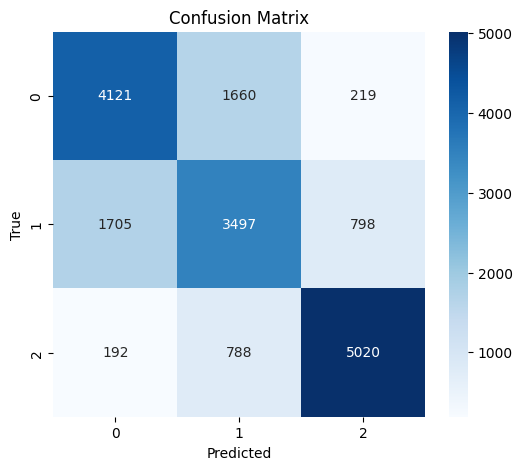

In [20]:
cm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [21]:
def predict_sentiment(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])
    pred = svm_model.predict(vec)
    
    return pred[0]

In [22]:
predict_sentiment("Качество хорошее]")

'positive'